#**BIBLIOTECAS INICIAIS**

In [2]:
import re  # achar padroes nos textos
import string # pontuações
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer # Ferramenta para reduzir palavras à raiz
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

#**CONFIGURAÇÃO INICIAL E DOWNLOADS**

In [4]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4') # As vezes necessário para o lemmatizer funcionar bem

stop_words = set(stopwords.words('english'))

# Inicializamos o Lematizador (o "cortador de sufixos")
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


#**1. FUNÇÃO DE PRÉ-PROCESSAMENTO**

In [5]:
def clean_text(text):
    text = str(text)

    text = text.lower()

    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>', '', text)
    text = re.sub(f'[{re.escape(string.punctuation)}]', '', text)
    text = re.sub('\n', ' ', text)
    text = re.sub('\w*\d\w*', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]

    return ' '.join(words)

<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
<>:6: SyntaxWarning: invalid escape sequence '\S'
<>:10: SyntaxWarning: invalid escape sequence '\w'
/tmp/ipython-input-2848630854.py:6: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
/tmp/ipython-input-2848630854.py:10: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


# **2. CARREGAMENTO E LIMPEZA DE DADOS**

In [6]:
# engine='python' e on_bad_lines='skip' tratam as linhas mal formatadas
df_train = pd.read_csv('train.csv', engine='python', on_bad_lines='skip')

df_test = pd.read_csv('test.csv', engine='python', on_bad_lines='skip')

print("Limpando dataset de Treino...")
df_train['text_clean'] = df_train['text'].apply(clean_text)
print("Limpo!\n")

print("Limpando dataset de Teste...")
df_test['text_clean'] = df_test['text'].apply(clean_text)
print("Limpo!")

Limpando dataset de Treino...
Limpo!

Limpando dataset de Teste...
Limpo!


#**3. VETORIZAÇÃO (TF-IDF)**

In [8]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

print("Vetorizando o texto de treino... (Isso pode demorar um pouco)")
X = tfidf.fit_transform(df_train['text_clean']).toarray()
y = df_train['label'] # Nossas respostas (Gabarito)

# Transform no teste (usando o vocabulário aprendido no treino)
X_test_kaggle = tfidf.transform(df_test['text_clean']).toarray()

print("Matriz TF-IDF criada. Tamanho:", X.shape)

Vetorizando o texto de treino... (Isso pode demorar um pouco)
Matriz TF-IDF criada. Tamanho: (22844, 5000)


# **4. DIVISÃO TREINO / VALIDAÇÃO**

In [9]:
# vou dividir o arquivo de trieno internamente para saber se o modelo está bom antes de submeter
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# stratify=y garante que a proporção de fake/real seja a mesma no treino e na validação.

# **5. TREINAMENTO DO MODELO (BASELINE)**

In [10]:
print("Treinando Regressão Logística...")
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

Treinando Regressão Logística...


LogisticRegression(random_state=42)

 # **6. AVALIAÇÃO E EXPLICABILIDADE**


RESULTADOS NA VALIDAÇÃO
F1-Score: 0.9629
------------------------------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3427
           1       1.00      0.93      0.96      1142

    accuracy                           0.98      4569
   macro avg       0.99      0.97      0.98      4569
weighted avg       0.98      0.98      0.98      4569



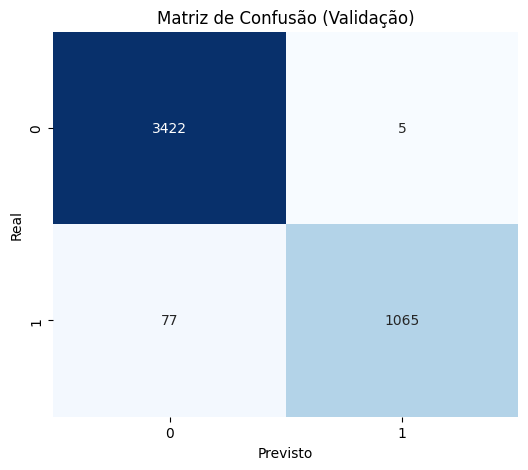

In [11]:
y_pred = model.predict(X_val)

# Métricas
f1 = f1_score(y_val, y_pred)
print(f"\nRESULTADOS NA VALIDAÇÃO")
print(f"F1-Score: {f1:.4f}")
print("-" * 30)
print(classification_report(y_val, y_pred))

# Matriz de Confusão
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de Confusão (Validação)')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

In [12]:
# Explicabilidade: Pesos das palavras
feature_names = tfidf.get_feature_names_out()
coefs = model.coef_[0]
df_weights = pd.DataFrame({'word': feature_names, 'weight': coefs})

print("\nTOP 10 PALAVRAS INDICATIVAS DE FAKE NEWS")
print(df_weights.sort_values(by='weight', ascending=False).head(10))

print("\nTOP 10 PALAVRAS INDICATIVAS DE NOTÍCIA REAL")
print(df_weights.sort_values(by='weight', ascending=True).head(10))


TOP 10 PALAVRAS INDICATIVAS DE FAKE NEWS
                 word    weight
4758              via  6.363320
2039            image  5.395295
3269  president trump  3.665241
1800              gop  3.598758
1943          hillary  3.553707
2454             like  3.402235
2040        image via  3.394680
2762               mr  3.336599
174          american  3.310427
1447             even  3.242204

TOP 10 PALAVRAS INDICATIVAS DE NOTÍCIA REAL
                    word     weight
3791                said -13.710217
3674             reuters -12.974291
4831  washington reuters  -5.933677
2213                  it  -4.323093
4840                  we  -4.062311
4828          washington  -3.927739
4855           wednesday  -3.902794
4635             tuesday  -3.788226
3262    president donald  -3.752575
4443                 the  -3.734493


# **7. GERAÇÃO DA SUBMISSÃO DO KAGGLE**

In [13]:
print("\nGerando arquivo de submissão...")
predictions_kaggle = model.predict(X_test_kaggle)

submission = pd.DataFrame({
    'id': df_test['id'],
    'target': predictions_kaggle
})

submission.to_csv('submissao_baseline_pep8.csv', index=False)
print("Arquivo 'submissao_baseline_pep8.csv' salvo com sucesso!")


Gerando arquivo de submissão...
Arquivo 'submissao_baseline_pep8.csv' salvo com sucesso!


#**8. ARTEFATOS DO MODELO**

In [14]:
import joblib

# Salvando o modelo treinado em um arquivo
joblib.dump(model, 'modelo_lr.joblib')

# Salvando o vetorizador (TF-IDF) em um arquivo
joblib.dump(tfidf, 'vetorizador_tfidf.joblib')

print("Arquivos do modelo foram criados com sucesso!")

Meus arquivos do modelo foram criados com sucesso!
